# Modelling & Evaluasi Klasifikasi untuk Deteksi Abnormalitas ECG
## Import Library

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, f1_score

plt.style.use('default')
sns.set_palette("Set2")

## Muat Data yang Sudah Dipreproses & Balanced

In [13]:
# Muat data yang sudah melalui preprocessing dan balancing
X_train = np.load('ECG200/X_train_bal.npy')
y_train = np.load('ECG200/y_train_bal.npy')
X_test = np.load('ECG200/X_test_bal.npy')
y_test = np.load('ECG200/y_test_bal.npy')

print(f"✅ Data dimuat untuk benchmarking:")
print(f"  - Train: {X_train.shape} | Label: {np.unique(y_train, return_counts=True)}")
print(f"  - Test : {X_test.shape}  | Label: {np.unique(y_test, return_counts=True)}")

✅ Data dimuat untuk benchmarking:
  - Train: (138, 96) | Label: (array([-1,  1]), array([69, 69]))
  - Test : (100, 96)  | Label: (array([-1,  1]), array([36, 64]))


## Training & Benchmarking Loop

In [14]:
print("🚀 MEMULAI BENCHMARKING MODEL: Evaluasi Multi-Algoritma pada Dataset ECG200\n")

# Daftar model
models = {
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "SVM (RBF)": SVC(kernel='rbf', probability=True, random_state=42)
}

results = []
rank = 1

for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    elapsed = time.time() - start
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'F1_Score': f1,
        'Time (s)': elapsed,
        'Model_Obj': model
    })
    
    # Tampilkan per model dengan gaya log
    print(f"[{rank:02}] {name}")
    print(f"     → Akurasi : {acc:.4f}")
    print(f"     → F1-Score: {f1:.4f}")
    print(f"     → Waktu   : {elapsed:.4f} detik\n")
    rank += 1

# Urutkan & tentukan pemenang
df_results = pd.DataFrame(results).sort_values('F1_Score', ascending=False).reset_index(drop=True)
winner = df_results.iloc[0]

print("🏆 MODEL TERBAIK BERDASARKAN F1-SCORE:")
print(f"   Nama     : {winner['Model']}")
print(f"   F1-Score : {winner['F1_Score']:.4f}")
print(f"   Akurasi  : {winner['Accuracy']:.4f}")
print(f"   Waktu    : {winner['Time (s)']:.4f} detik")

🚀 MEMULAI BENCHMARKING MODEL: Evaluasi Multi-Algoritma pada Dataset ECG200

[01] Naive Bayes
     → Akurasi : 0.7900
     → F1-Score: 0.7838
     → Waktu   : 0.0041 detik

[02] Logistic Regression
     → Akurasi : 0.8300
     → F1-Score: 0.8222
     → Waktu   : 0.0116 detik

[03] Decision Tree
     → Akurasi : 0.8100
     → F1-Score: 0.7926
     → Waktu   : 0.0093 detik

[04] Random Forest
     → Akurasi : 0.8200
     → F1-Score: 0.8069
     → Waktu   : 0.1478 detik

[05] KNN (k=5)
     → Akurasi : 0.8800
     → F1-Score: 0.8727
     → Waktu   : 0.0029 detik

[06] SVM (RBF)
     → Akurasi : 0.8600
     → F1-Score: 0.8514
     → Waktu   : 0.0061 detik

🏆 MODEL TERBAIK BERDASARKAN F1-SCORE:
   Nama     : KNN (k=5)
   F1-Score : 0.8727
   Akurasi  : 0.8800
   Waktu    : 0.0029 detik


## Visualisasi Komparasi Model


VISUALISASI KOMPARASI MODEL (Diagram Batang)


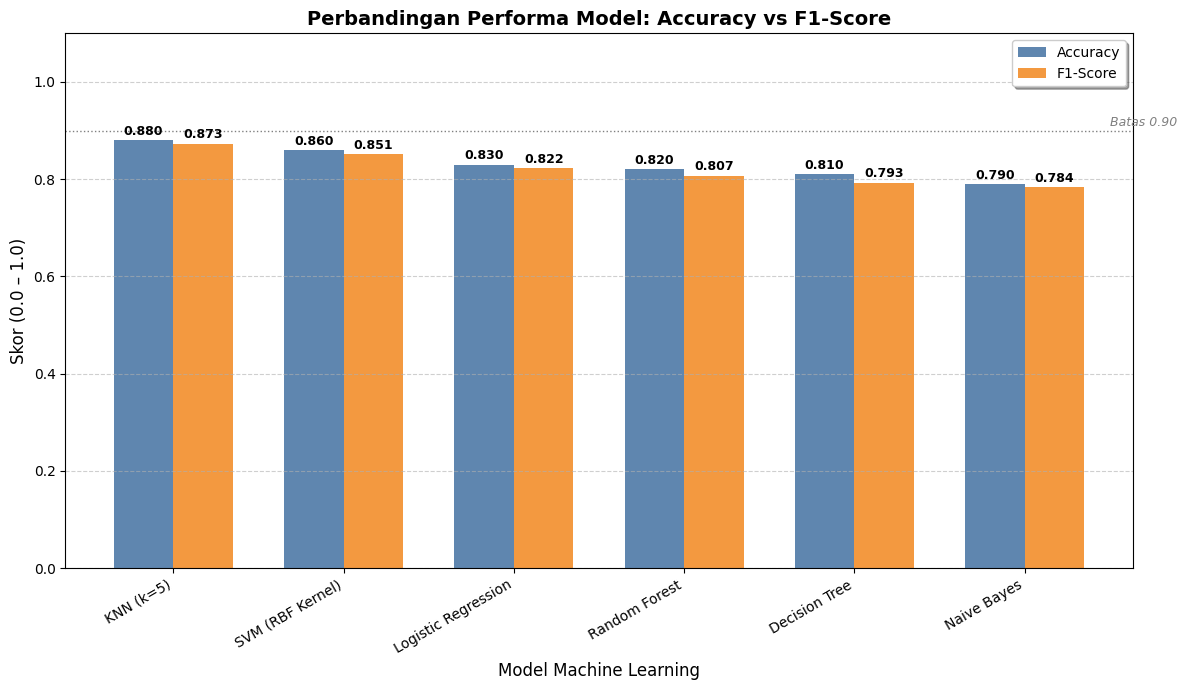


📊 Interpretasi:
   - Batang biru = Akurasi, oranye = F1-Score.
   - Semakin tinggi dan sejajar kedua batang, semakin stabil modelnya.
   - Model dengan batang >0.90 dianggap sangat baik untuk dataset ini.


In [21]:
print("\nVISUALISASI KOMPARASI MODEL (Diagram Batang)")

# Urutkan berdasarkan F1-Score (seperti hasil benchmarking)
df_plot = df_results.sort_values('F1_Score', ascending=False)

# Buat posisi untuk bar
x = np.arange(len(df_plot))
width = 0.35  # Lebar tiap batang

# Buat figur
plt.figure(figsize=(12, 7))
ax = plt.subplot(111)

# Plot dua metrik berdampingan
bars1 = ax.bar(x - width/2, df_plot['Accuracy'], width, label='Accuracy', color='#4E79A7', alpha=0.9)
bars2 = ax.bar(x + width/2, df_plot['F1_Score'],  width, label='F1-Score',  color='#F28E2B', alpha=0.9)

# Tambahkan nilai di atas batang
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Pengaturan sumbu
ax.set_xlabel('Model Machine Learning', fontsize=12)
ax.set_ylabel('Skor (0.0 – 1.0)', fontsize=12)
ax.set_title('Perbandingan Performa Model: Accuracy vs F1-Score', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df_plot['Model'], rotation=30, ha='right')
ax.set_ylim(0, 1.1)
ax.legend(loc='upper right', frameon=True, shadow=True)
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Tambahkan garis horizontal di skor 0.9 sebagai referensi
ax.axhline(0.9, color='gray', linestyle=':', linewidth=1)
ax.text(len(df_plot)-0.5, 0.91, 'Batas 0.90', fontsize=9, color='gray', style='italic')

plt.tight_layout()
plt.show()

print("\n📊 Interpretasi:")
print("   - Batang biru = Akurasi, oranye = F1-Score.")
print("   - Semakin tinggi dan sejajar kedua batang, semakin stabil modelnya.")
print("   - Model dengan batang >0.90 dianggap sangat baik untuk dataset ini.")

## Simpan Model Terbaik

In [19]:
import joblib

# Simpan model terbaik untuk deploy
joblib.dump(best_model_obj, 'ECG200/best_model.pkl')
print(f"\n💾 Model terbaik ({best_model_name}) berhasil disimpan sebagai 'ECG200/best_model.pkl'")


💾 Model terbaik (KNN (k=5)) berhasil disimpan sebagai 'ECG200/best_model.pkl'


# Evaluasi 

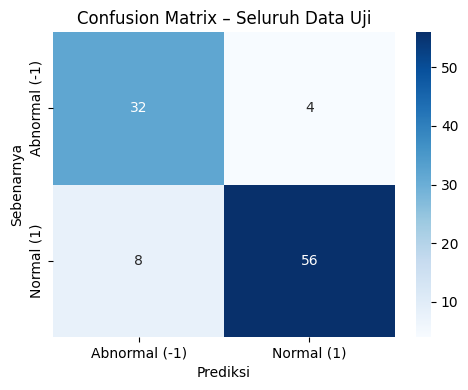


🔍 Prediksi untuk sampel index 0:
   - Input: 96 titik waktu (1 deret ECG)
   - Output model: 1 nilai (1 kolom prediksi kelas)
   - Label sebenarnya: 1 → Normal
   - Prediksi model   : 1 → Normal
   ✅ Prediksi BENAR!


In [17]:
import numpy as np
import pandas as pd
from scipy.io import arff
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

model = joblib.load('ECG200/best_model.pkl')
scaler = joblib.load('ECG200/scaler.pkl')

data_test, _ = arff.loadarff('ECG200/ECG200_TEST.arff')
df_test = pd.DataFrame(data_test)

X_test_raw = df_test.iloc[:, :-1].values
y_test_true = df_test['target'].apply(lambda x: 1 if x == b'1' else -1).values

X_test_scaled = scaler.transform(X_test_raw)

y_test_pred = model.predict(X_test_scaled)

cm = confusion_matrix(y_test_true, y_test_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Abnormal (-1)', 'Normal (1)'],
            yticklabels=['Abnormal (-1)', 'Normal (1)'])
plt.title('Confusion Matrix – Seluruh Data Uji')
plt.xlabel('Prediksi')
plt.ylabel('Sebenarnya')
plt.tight_layout()
plt.show()

sample_index = 0
y_true = y_test_true[sample_index]
y_pred = y_test_pred[sample_index]

print(f"\n🔍 Prediksi untuk sampel index {sample_index}:")
print(f"   - Input: 96 titik waktu (1 deret ECG)")
print(f"   - Output model: 1 nilai (1 kolom prediksi kelas)")
print(f"   - Label sebenarnya: {y_true} → {'Normal' if y_true == 1 else 'Abnormal'}")
print(f"   - Prediksi model   : {y_pred} → {'Normal' if y_pred == 1 else 'Abnormal'}")

if y_true == y_pred:
    print("   ✅ Prediksi BENAR!")
else:
    print("   ❌ Prediksi SALAH!")